In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available  : {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cpu
GPU available  : False


In [2]:
# A tensor is the fundamental data structure in PyTorch
# Think of it as a numpy array but with GPU support and autograd

# 0-D tensor (scalar) — a single number
integer = torch.tensor(1234)
decimal = torch.tensor(3.14159265359)

print(f"`integer` is a {integer.ndim}-d Tensor: {integer}")
print(f"`decimal` is a {decimal.ndim}-d Tensor: {decimal}")

# 1-D tensor (vector)
fibonacci     = torch.tensor([1, 1, 2, 3, 5, 8])
count_to_100  = torch.tensor(range(100))

print(f"\n`fibonacci` is a {fibonacci.ndim}-d Tensor with shape: {fibonacci.shape}")
print(f"`count_to_100` is a {count_to_100.ndim}-d Tensor with shape: {count_to_100.shape}")

`integer` is a 0-d Tensor: 1234
`decimal` is a 0-d Tensor: 3.1415927410125732

`fibonacci` is a 1-d Tensor with shape: torch.Size([6])
`count_to_100` is a 1-d Tensor with shape: torch.Size([100])


In [3]:
# ── TODO 1: Define a 2-D Tensor (matrix) ──────────────────────────────────
# A 2D tensor is a matrix — rows and columns
# torch.ones(rows, cols) creates a matrix filled with 1s
matrix = torch.ones(3, 4)   # 3 rows, 4 columns

assert isinstance(matrix, torch.Tensor), "matrix must be a torch Tensor object"
assert matrix.ndim == 2
print(f"`matrix` is a {matrix.ndim}-d Tensor with shape: {matrix.shape}")
print(matrix)

# ── TODO 2: Define a 4-D Tensor ───────────────────────────────────────────
# 4D tensors are the standard for image batches in deep learning
# Shape: (batch_size, channels, height, width)
# 10 images, RGB (3 channels), 256×256 pixels each
images = torch.zeros(10, 3, 256, 256)

assert isinstance(images, torch.Tensor), "images must be a torch Tensor object"
assert images.ndim == 4,                 "images must have 4 dimensions"
assert images.shape == (10, 3, 256, 256),"images is incorrect shape"

print(f"\n`images` is a {images.ndim}-d Tensor with shape: {images.shape}")
print(f"Interpretation: {images.shape[0]} images, "
      f"{images.shape[1]} channels (RGB), "
      f"{images.shape[2]}×{images.shape[3]} pixels each")

`matrix` is a 2-d Tensor with shape: torch.Size([3, 4])
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

`images` is a 4-d Tensor with shape: torch.Size([10, 3, 256, 256])
Interpretation: 10 images, 3 channels (RGB), 256×256 pixels each


In [4]:
# Slicing works exactly like NumPy
# matrix shape is (3, 4)

row_vector    = matrix[1]       # entire second row
column_vector = matrix[:, 1]   # entire second column (all rows, col index 1)
scalar        = matrix[0, 1]   # single element at row 0, col 1

print(f"`row_vector`    : {row_vector}")
print(f"`column_vector` : {column_vector}")
print(f"`scalar`        : {scalar}")

# Why slicing matters in DL:
# images[0]        → first image  (3, 256, 256)
# images[:, 0]     → red channel of all images  (10, 256, 256)
# images[0, :, :10, :10] → top-left 10×10 patch of first image, all channels
print(f"\nFirst image shape      : {images[0].shape}")
print(f"Red channel all images : {images[:, 0].shape}")

`row_vector`    : tensor([1., 1., 1., 1.])
`column_vector` : tensor([1., 1., 1.])
`scalar`        : 1.0

First image shape      : torch.Size([3, 256, 256])
Red channel all images : torch.Size([10, 256, 256])


In [5]:
# PyTorch builds a computation graph dynamically as operations execute
# Every operation on tensors is tracked — this enables autograd (backprop)

a = torch.tensor(15)
b = torch.tensor(61)

c1 = torch.add(a, b)   # explicit add function
c2 = a + b             # operator overloading — same result

print(f"c1 (torch.add) : {c1}")
print(f"c2 (a + b)     : {c2}")
print(f"Both equal     : {c1 == c2}")

c1 (torch.add) : 76
c2 (a + b)     : 76
Both equal     : True


In [6]:
# The lab shows this computation graph:
#   c = a + b
#   d = b + 1
#   e = c * d
# Let's implement it

def func(a, b):
    # TODO: Define c, d, e
    c = a + b       # sum of inputs
    d = b + 1       # b incremented
    e = c * d       # product of the two intermediate values
    return e

# Test with given values
a, b  = 1.5, 2.5
e_out = func(a, b)
print(f"a={a}, b={b}")
print(f"c = a+b = {a+b}")
print(f"d = b+1 = {b+1}")
print(f"e = c*d = {(a+b)*(b+1)}")
print(f"e_out   : {e_out}")

# PyTorch version — tensors track the graph
a_t = torch.tensor(1.5)
b_t = torch.tensor(2.5)
e_t = func(a_t, b_t)
print(f"\nTensor result: {e_t}   (same value, now a tensor)")

a=1.5, b=2.5
c = a+b = 4.0
d = b+1 = 3.5
e = c*d = 14.0
e_out   : 14.0

Tensor result: 14.0   (same value, now a tensor)


In [7]:
# This is the most important TODO in the lab
# We build a Dense (fully connected) layer manually
# to understand exactly what nn.Linear does internally

class OurDenseLayer(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super(OurDenseLayer, self).__init__()

        # Weight matrix W: shape (num_inputs, num_outputs)
        # Each column = weights for one output neuron
        self.W    = nn.Parameter(torch.randn(num_inputs, num_outputs))

        # Bias vector: one bias per output neuron
        self.bias = nn.Parameter(torch.randn(num_outputs))

    def forward(self, x):
        # TODO: z = x @ W + bias  (matrix multiply input by weights, add bias)
        z = torch.matmul(x, self.W) + self.bias

        # TODO: apply sigmoid activation
        y = torch.sigmoid(z)

        return y


# Test the layer
num_inputs  = 2
num_outputs = 3
layer   = OurDenseLayer(num_inputs, num_outputs)
x_input = torch.tensor([[1, 2.]])   # shape (1, 2) — batch of 1, 2 features

y = layer(x_input)
print(f"Input  shape : {x_input.shape}")
print(f"Output shape : {y.shape}")    # (1, 3) — batch of 1, 3 outputs
print(f"Output result: {y}")
print(f"\nW shape : {layer.W.shape}")
print(f"b shape : {layer.bias.shape}")

# What just happened:
# z = [1, 2] @ W(2×3) + b(3) = vector of 3 values
# y = sigmoid(z) = 3 probabilities between 0 and 1

Input  shape : torch.Size([1, 2])
Output shape : torch.Size([1, 3])
Output result: tensor([[0.4480, 0.2424, 0.9670]], grad_fn=<SigmoidBackward0>)

W shape : torch.Size([2, 3])
b shape : torch.Size([3])


In [8]:
# nn.Sequential stacks layers linearly — same as Keras Sequential
# Much cleaner than writing the class manually for simple networks

n_input_nodes  = 2
n_output_nodes = 3

# TODO: Sequential model with one Linear layer + Sigmoid
model = nn.Sequential(
    nn.Linear(n_input_nodes, n_output_nodes),  # Dense layer
    nn.Sigmoid()                                # Activation
)

x_input      = torch.tensor([[1, 2.]])
model_output = model(x_input)

print(f"Input  shape : {x_input.shape}")
print(f"Output shape : {model_output.shape}")
print(f"Output result: {model_output}")

# Inspect what Sequential contains
print("\nModel architecture:")
print(model)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")
print(f"  Linear weights : {n_input_nodes * n_output_nodes}  (2×3)")
print(f"  Linear biases  : {n_output_nodes}  (one per output)")

Input  shape : torch.Size([1, 2])
Output shape : torch.Size([1, 3])
Output result: tensor([[0.5237, 0.6897, 0.6760]], grad_fn=<SigmoidBackward0>)

Model architecture:
Sequential(
  (0): Linear(in_features=2, out_features=3, bias=True)
  (1): Sigmoid()
)

Total parameters: 9
  Linear weights : 6  (2×3)
  Linear biases  : 3  (one per output)


In [9]:
# nn.Module subclassing — the proper PyTorch way
# More flexible than Sequential — allows custom forward logic

class LinearWithSigmoidActivation(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super(LinearWithSigmoidActivation, self).__init__()

        # TODO: define Linear layer and Sigmoid activation as attributes
        self.linear     = nn.Linear(num_inputs, num_outputs)
        self.activation = nn.Sigmoid()

    def forward(self, inputs):
        linear_output = self.linear(inputs)
        output        = self.activation(linear_output)
        return output


# Test
n_input_nodes  = 2
n_output_nodes = 3

model   = LinearWithSigmoidActivation(n_input_nodes, n_output_nodes)
x_input = torch.tensor([[1, 2.]])
y       = model(x_input)

print(f"Input  shape : {x_input.shape}")
print(f"Output shape : {y.shape}")
print(f"Output result: {y}")

Input  shape : torch.Size([1, 2])
Output shape : torch.Size([1, 3])
Output result: tensor([[0.3613, 0.3788, 0.5930]], grad_fn=<SigmoidBackward0>)


In [10]:
# This shows the flexibility of nn.Module subclassing
# The forward() function can contain any Python logic
# including conditionals — impossible with Sequential

class LinearButSometimesIdentity(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super(LinearButSometimesIdentity, self).__init__()
        self.linear = nn.Linear(num_inputs, num_outputs)

    def forward(self, inputs, isidentity=False):
        # TODO: if isidentity=True, return input unchanged
        #       otherwise apply the linear transformation
        if isidentity:
            return inputs          # pass input through unchanged
        else:
            return self.linear(inputs)


# Test both behaviors
model   = LinearButSometimesIdentity(num_inputs=2, num_outputs=3)
x_input = torch.tensor([[1, 2.]])

# TODO: call with and without identity
out_with_linear   = model(x_input, isidentity=False)
out_with_identity = model(x_input, isidentity=True)

print(f"Input                : {x_input}")
print(f"Linear output shape  : {out_with_linear.shape}    → {out_with_linear}")
print(f"Identity output shape: {out_with_identity.shape}  → {out_with_identity}")
print("\nWhen isidentity=True: input passes through unchanged — no transformation.")
print("When isidentity=False: normal linear layer computation.")

Input                : tensor([[1., 2.]])
Linear output shape  : torch.Size([1, 3])    → tensor([[-0.0360,  0.3514, -0.8678]], grad_fn=<AddmmBackward0>)
Identity output shape: torch.Size([1, 2])  → tensor([[1., 2.]])

When isidentity=True: input passes through unchanged — no transformation.
When isidentity=False: normal linear layer computation.


In [11]:
# autograd is PyTorch's automatic differentiation engine
# It tracks every operation on tensors with requires_grad=True
# and computes gradients automatically via .backward()

# y = x²   →   dy/dx = 2x   →   at x=3.0, dy/dx = 6.0
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

# backward() computes dy/dx using the chain rule
y.backward()

dy_dx = x.grad
print(f"y = x²  at x = 3.0")
print(f"dy/dx   = 2x = 2×3 = 6")
print(f"PyTorch : {dy_dx}")

assert dy_dx == 6.0
print("Assertion passed ✓")

y = x²  at x = 3.0
dy/dx   = 2x = 2×3 = 6
PyTorch : 6.0
Assertion passed ✓


Target x_f = 4.0
Starting x = 0.0000

 Step           x          Loss
--------------------------------
    0      0.8000     16.000000
    5      2.9514      1.717987
   10      3.6564      0.184467
   15      3.8874      0.019807
   20      3.9631      0.002127
   25      3.9879      0.000228
   30      3.9960      0.000025
   35      3.9987      0.000003
   40      3.9996      0.000000
   45      3.9999      0.000000

Final x    : 3.999943
Target x_f : 4.0
Difference : 0.00005698


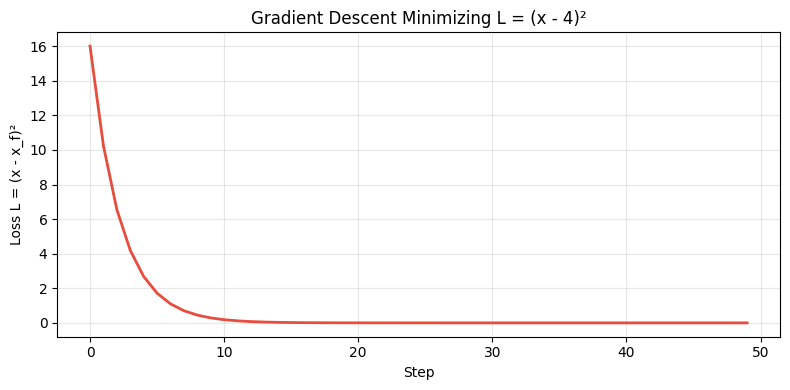

In [12]:
# Find minimum of L = (x - x_f)²
# Analytical answer: x_min = x_f
# Let's verify PyTorch gradient descent finds the same answer

x_f = 4.0   # target value we want x to converge to

# Start x at a random point
x   = torch.tensor([0.0], requires_grad=True)

# Optimizer — plain SGD with learning rate 0.1
optimizer = torch.optim.SGD([x], lr=0.1)

loss_history = []

print(f"Target x_f = {x_f}")
print(f"Starting x = {x.item():.4f}\n")
print(f"{'Step':>5}  {'x':>10}  {'Loss':>12}")
print("-" * 32)

for step in range(50):
    optimizer.zero_grad()          # clear gradients from last step
    loss = (x - x_f) ** 2         # compute loss
    loss.backward()                # compute dL/dx automatically
    optimizer.step()               # x = x - lr * dL/dx

    loss_history.append(loss.item())

    if step % 5 == 0:
        print(f"{step:>5}  {x.item():>10.4f}  {loss.item():>12.6f}")

print(f"\nFinal x    : {x.item():.6f}")
print(f"Target x_f : {x_f}")
print(f"Difference : {abs(x.item() - x_f):.8f}")

# Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='#e74c3c', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss L = (x - x_f)²')
plt.title('Gradient Descent Minimizing L = (x - 4)²', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Training   : torch.Size([800, 2]) features,  torch.Size([800, 1]) labels
Test       : torch.Size([200, 2])  features,  torch.Size([200, 1])  labels


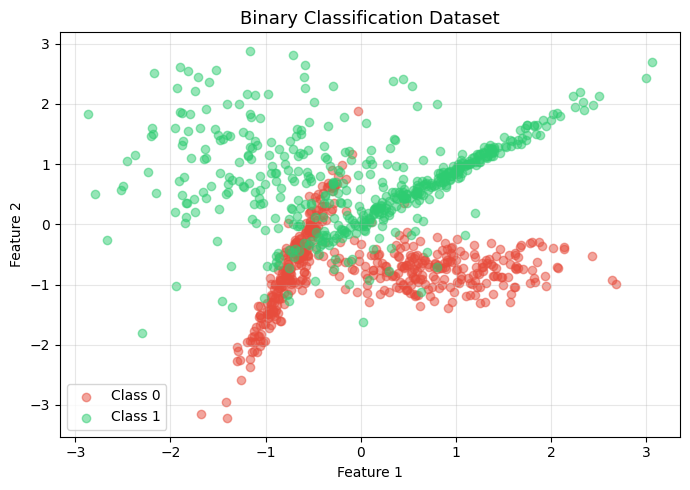

In [13]:
# Binary classification — two gaussian blobs
# This is the kind of data a real classifier would see
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples    = 1000,
    n_features   = 2,       # 2 features so we can visualize
    n_informative= 2,
    n_redundant  = 0,
    random_state = 42
)

# Scale features — mandatory for neural networks
scaler  = StandardScaler()
X       = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)  # shape (n, 1) for BCE loss
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

print(f"Training   : {X_train_t.shape} features,  {y_train_t.shape} labels")
print(f"Test       : {X_test_t.shape}  features,  {y_test_t.shape}  labels")

# Visualize the dataset
plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], alpha=0.5, color='#e74c3c', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], alpha=0.5, color='#2ecc71', label='Class 1')
plt.title('Binary Classification Dataset', fontsize=13)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# A proper neural network using nn.Module subclassing
# 2 inputs → 16 → 8 → 1 output (sigmoid for binary classification)

class BinaryClassifier(nn.Module):
    def __init__(self):
        super(BinaryClassifier, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


model = BinaryClassifier()
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params}")

# Breakdown
for name, param in model.named_parameters():
    print(f"  {name:<25} shape: {str(list(param.shape)):<15}  params: {param.numel()}")

BinaryClassifier(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Total trainable parameters: 193
  network.0.weight          shape: [16, 2]          params: 32
  network.0.bias            shape: [16]             params: 16
  network.2.weight          shape: [8, 16]          params: 128
  network.2.bias            shape: [8]              params: 8
  network.4.weight          shape: [1, 8]           params: 8
  network.4.bias            shape: [1]              params: 1


In [16]:
# This is what Keras .fit() hides from you
# Writing it manually gives you full control and understanding

criterion = nn.BCELoss()                                    # Binary Cross-Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Adam

train_losses = []
test_losses  = []
train_accs   = []
test_accs    = []

EPOCHS = 100

for epoch in range(EPOCHS):

    # ── TRAINING PHASE ──────────────────────────────────────────────────
    model.train()                          # enable training mode (dropout etc active)
    optimizer.zero_grad()                  # 1. clear gradients from previous step
    y_pred = model(X_train_t)             # 2. forward pass
    loss   = criterion(y_pred, y_train_t) # 3. compute loss
    loss.backward()                        # 4. backpropagation (compute all gradients)
    optimizer.step()                       # 5. update weights

    # Training accuracy
    predicted_cls = (y_pred >= 0.5).float()
    train_acc = (predicted_cls == y_train_t).float().mean().item() * 100

    # ── VALIDATION PHASE ─────────────────────────────────────────────────
    model.eval()                           # disable training mode
    with torch.no_grad():                  # no gradient tracking needed for eval
        y_test_pred  = model(X_test_t)
        test_loss    = criterion(y_test_pred, y_test_t)
        test_cls     = (y_test_pred >= 0.5).float()
        test_acc     = (test_cls == y_test_t).float().mean().item() * 100

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:>3}/{EPOCHS}]  "
              f"Train Loss: {loss.item():.4f}  "
              f"Train Acc: {train_acc:.1f}%  "
              f"Test Loss: {test_loss.item():.4f}  "
              f"Test Acc: {test_acc:.1f}%")

Epoch [ 10/100]  Train Loss: 0.5819  Train Acc: 84.9%  Test Loss: 0.5606  Test Acc: 87.0%
Epoch [ 20/100]  Train Loss: 0.4283  Train Acc: 86.0%  Test Loss: 0.3856  Test Acc: 88.5%
Epoch [ 30/100]  Train Loss: 0.3414  Train Acc: 86.1%  Test Loss: 0.2834  Test Acc: 88.0%
Epoch [ 40/100]  Train Loss: 0.3336  Train Acc: 86.4%  Test Loss: 0.2707  Test Acc: 87.5%
Epoch [ 50/100]  Train Loss: 0.3189  Train Acc: 86.1%  Test Loss: 0.2653  Test Acc: 87.5%
Epoch [ 60/100]  Train Loss: 0.3138  Train Acc: 87.0%  Test Loss: 0.2646  Test Acc: 88.0%
Epoch [ 70/100]  Train Loss: 0.3077  Train Acc: 86.8%  Test Loss: 0.2571  Test Acc: 88.0%
Epoch [ 80/100]  Train Loss: 0.3010  Train Acc: 86.6%  Test Loss: 0.2500  Test Acc: 88.0%
Epoch [ 90/100]  Train Loss: 0.2914  Train Acc: 87.3%  Test Loss: 0.2443  Test Acc: 88.0%
Epoch [100/100]  Train Loss: 0.2798  Train Acc: 88.7%  Test Loss: 0.2346  Test Acc: 89.5%


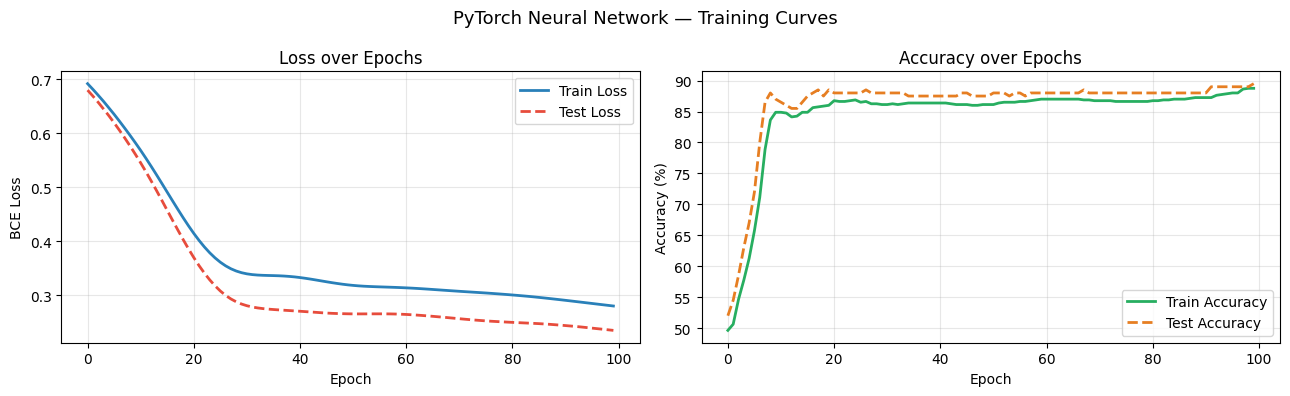

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, label='Train Loss', color='#2980b9', linewidth=2)
axes[0].plot(test_losses,  label='Test Loss',  color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Loss over Epochs', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, label='Train Accuracy', color='#27ae60', linewidth=2)
axes[1].plot(test_accs,  label='Test Accuracy',  color='#e67e22', linewidth=2, linestyle='--')
axes[1].set_title('Accuracy over Epochs', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('PyTorch Neural Network — Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

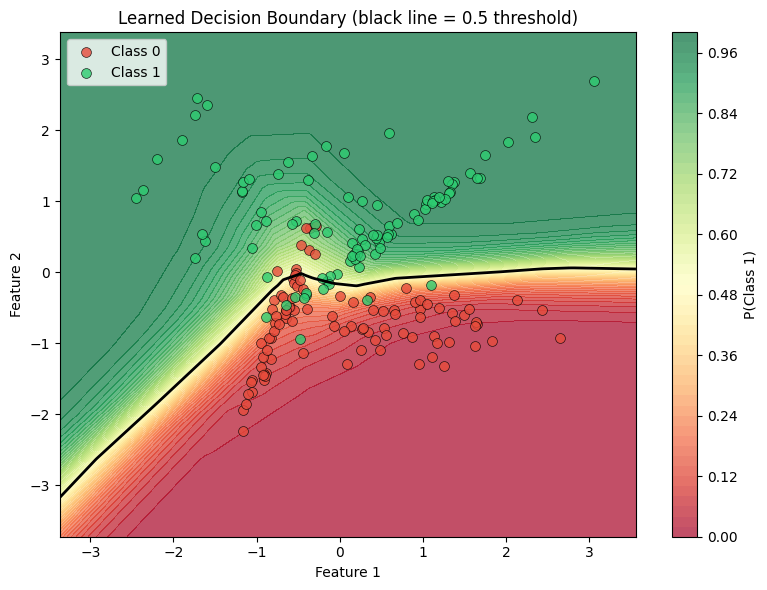

In [18]:
# Visualize what the trained network learned
model.eval()

# Create a mesh grid over the feature space
x1_range = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300)
x2_range = np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300)
xx, yy   = np.meshgrid(x1_range, x2_range)
grid     = np.c_[xx.ravel(), yy.ravel()]

grid_tensor = torch.FloatTensor(grid)
with torch.no_grad():
    Z = model(grid_tensor).numpy().reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=50, cmap='RdYlGn', alpha=0.7)
plt.colorbar(label='P(Class 1)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1],
            color='#e74c3c', label='Class 0', edgecolors='black',
            linewidths=0.5, s=50, alpha=0.8)
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1],
            color='#2ecc71', label='Class 1', edgecolors='black',
            linewidths=0.5, s=50, alpha=0.8)
plt.title('Learned Decision Boundary (black line = 0.5 threshold)', fontsize=12)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

     EXPERIMENT 2 — FINAL RESULTS
  Final Test Accuracy : 89.50%
  Final Test Loss     : 0.2346

--- Classification Report ---
              precision    recall  f1-score   support

     Class 0       0.89      0.90      0.90       101
     Class 1       0.90      0.89      0.89        99

    accuracy                           0.90       200
   macro avg       0.90      0.89      0.89       200
weighted avg       0.90      0.90      0.89       200



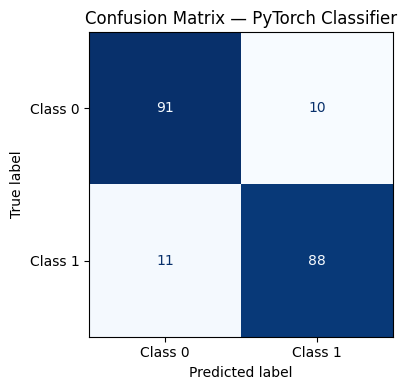

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
with torch.no_grad():
    y_pred_final = model(X_test_t)
    y_pred_cls   = (y_pred_final >= 0.5).numpy().astype(int).flatten()

print("=" * 50)
print("     EXPERIMENT 2 — FINAL RESULTS")
print("=" * 50)
print(f"  Final Test Accuracy : {test_accs[-1]:.2f}%")
print(f"  Final Test Loss     : {test_losses[-1]:.4f}")
print()
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_cls,
                            target_names=['Class 0', 'Class 1']))

# Confusion matrix
cm  = confusion_matrix(y_test, y_pred_cls)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Class 0', 'Class 1']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — PyTorch Classifier', fontsize=12)
plt.tight_layout()
plt.show()